# Notebook 4 — Multi-Modal Augmentation and Classification

This notebook extends augmentation beyond standard image classification and demonstrates augmentation strategies across multiple data modalities.

## Modalities covered

This notebook includes:

- text
- time series
- tabular data
- speech
- document images
- video

## Structure of each section

Each modality section follows the same pattern:

1. create or load a compact dataset,
2. train a baseline model without augmentation,
3. train the same model with augmentation,
4. compare training behavior, validation performance, and test accuracy.

## Main goal

The objective is to show that augmentation is a broad concept that applies to many data types, not only to images.  
The exact augmentation method changes with the modality, but the core idea remains the same: create more diverse training examples while preserving the label.


In [1]:
import os
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.19.0
Keras version: 3.13.2


## Reproducibility and configuration


In [2]:
SEED = 42

tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

AUTO = tf.data.AUTOTUNE
plt.rcParams["figure.figsize"] = (8, 4)


## Common training helpers

The helper functions below are reused across all modalities so that the notebook remains consistent and compact.


In [3]:
def compile_and_train(model,
                      train_data,
                      valid_data,
                      test_data,
                      loss,
                      metrics,
                      epochs=5,
                      learning_rate=1e-3,
                      verbose=0):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=metrics,
    )
    history = model.fit(
        train_data,
        validation_data=valid_data,
        epochs=epochs,
        verbose=verbose,
    )
    test_loss, test_acc = model.evaluate(test_data, verbose=0)
    return history, test_loss, test_acc

def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    hist[[c for c in hist.columns if "loss" in c and "val" not in c] + ["val_loss"]].plot(ax=axes[0], title=f"{title} - Loss")
    metric_cols = [c for c in hist.columns if c != "loss" and c != "val_loss"]
    if len(metric_cols) >= 2:
        hist[metric_cols[:2]].plot(ax=axes[1], title=f"{title} - Metric")
    axes[0].set_xlabel("Epoch")
    axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()

def summarize_run(name, history, test_acc, metric_name="accuracy"):
    hist = history.history
    train_key = metric_name
    val_key = f"val_{metric_name}"
    final_train = float(hist[train_key][-1])
    final_val = float(hist[val_key][-1])
    return {
        "experiment": name,
        "best_val_metric": float(np.max(hist[val_key])),
        "final_train_metric": final_train,
        "final_val_metric": final_val,
        "test_metric": float(test_acc),
        "epochs_ran": len(hist["loss"]),
        "generalization_gap": final_train - final_val,
    }

def compare_results(results):
    return pd.DataFrame(results).sort_values("test_metric", ascending=False).reset_index(drop=True)


# 1. Text augmentation and classification

This section demonstrates augmentation for short text classification.

## Task
A compact sentiment-style dataset is created with two labels:
- positive
- negative

## Augmentation strategy
The augmented training set is created using simple label-preserving transformations:
- synonym replacement,
- adverb insertion,
- random word deletion for longer sentences.

The purpose is to increase lexical variety without changing the target label.


In [4]:
import re
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 5000
max_words_per_review = 120
train_samples = 5000
test_samples = 2000

word_index = imdb.get_word_index()
index_to_word = {index + 3: word for word, index in word_index.items()}
index_to_word[0] = "<pad>"
index_to_word[1] = "<start>"
index_to_word[2] = "<unk>"
index_to_word[3] = "<unused>"

def decode_review(sequence):
    words = [index_to_word.get(int(token), "<unk>") for token in sequence]
    words = [w for w in words if w not in {"<pad>", "<start>", "<unk>", "<unused>"}]
    return " ".join(words[:max_words_per_review])

def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

def augment_text(sentence, label):
    words = sentence.split()
    if len(words) < 6:
        return sentence

    augmented = words.copy()

    # Random word dropout
    keep_words = []
    for i, word in enumerate(augmented):
        if i in (0, len(augmented) - 1) or random.random() > 0.12:
            keep_words.append(word)
    augmented = keep_words

    # Random local swap
    if len(augmented) > 8 and random.random() < 0.5:
        swap_idx = random.randint(1, len(augmented) - 3)
        augmented[swap_idx], augmented[swap_idx + 1] = augmented[swap_idx + 1], augmented[swap_idx]

    # Mild sentiment-preserving intensifier insertion
    if label == 1 and random.random() < 0.35:
        insert_idx = min(2, len(augmented))
        augmented.insert(insert_idx, "really")
    elif label == 0 and random.random() < 0.35:
        insert_idx = min(2, len(augmented))
        augmented.insert(insert_idx, "quite")

    return " ".join(augmented)

(raw_x_train, raw_y_train), (raw_x_test, raw_y_test) = imdb.load_data(num_words=vocab_size)

texts_train = [clean_text(decode_review(seq)) for seq in raw_x_train[:train_samples]]
texts_test = [clean_text(decode_review(seq)) for seq in raw_x_test[:test_samples]]

labels_train = np.array(raw_y_train[:train_samples], dtype=np.int32)
labels_test = np.array(raw_y_test[:test_samples], dtype=np.int32)

texts = np.array(texts_train + texts_test)
labels = np.concatenate([labels_train, labels_test], axis=0)

idx = np.random.permutation(len(texts))
texts = texts[idx]
labels = labels[idx]

n_train = int(0.7 * len(texts))
n_valid = int(0.85 * len(texts))

x_train_text = texts[:n_train]
y_train_text = labels[:n_train]
x_valid_text = texts[n_train:n_valid]
y_valid_text = labels[n_train:n_valid]
x_test_text = texts[n_valid:]
y_test_text = labels[n_valid:]

augmented_texts = np.array([augment_text(t, y) for t, y in zip(x_train_text, y_train_text)])
x_train_text_aug = np.concatenate([x_train_text, augmented_texts], axis=0)
y_train_text_aug = np.concatenate([y_train_text, y_train_text], axis=0)

print("Train:", len(x_train_text), "Augmented train:", len(x_train_text_aug), "Test:", len(x_test_text))
pd.DataFrame({"original": x_train_text[:8], "augmented": augmented_texts[:8], "label": y_train_text[:8]})

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: 4900 Augmented train: 9800 Test: 1050


,original,augmented,label
0,for those curious this episode is based in the...,for those really this episode is based in upon...,1
1,what was steven seagal thinking i mean firstly...,what was steven seagal thinking mean i love se...,0
2,the kids i took to this movie loved it four ch...,the kids really i took to this movie loved it ...,1
3,near the beginning after it's been established...,near beginning after it's been that john warre...,0
4,i'd always wanted david to go into the movie b...,i'd always wanted david to go into the movie a...,1
5,haven't seen this film haven't even heard of t...,haven't seen this film haven't even heard of t...,1
6,just plain isn't funny his show is painful to ...,just plain his show is to watch because of tha...,0
7,hey you are not alone i remember i was just 17...,hey you are not alone i remember i was just 17...,1


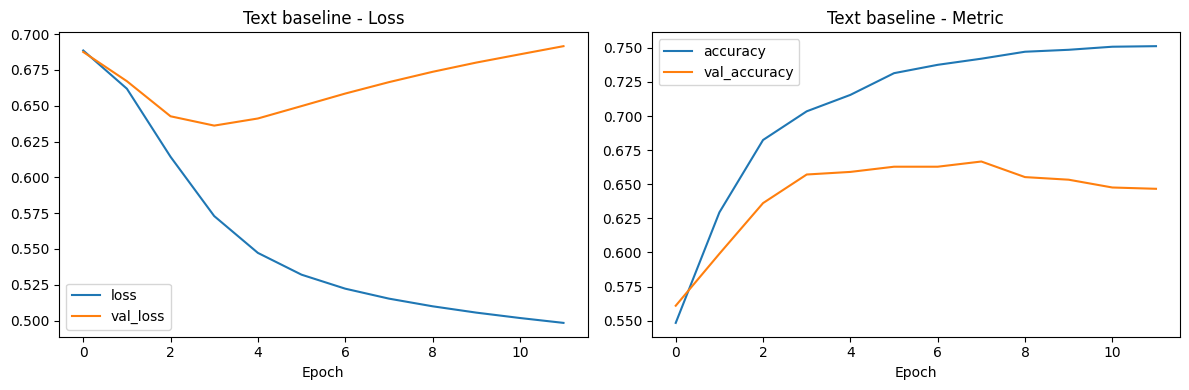

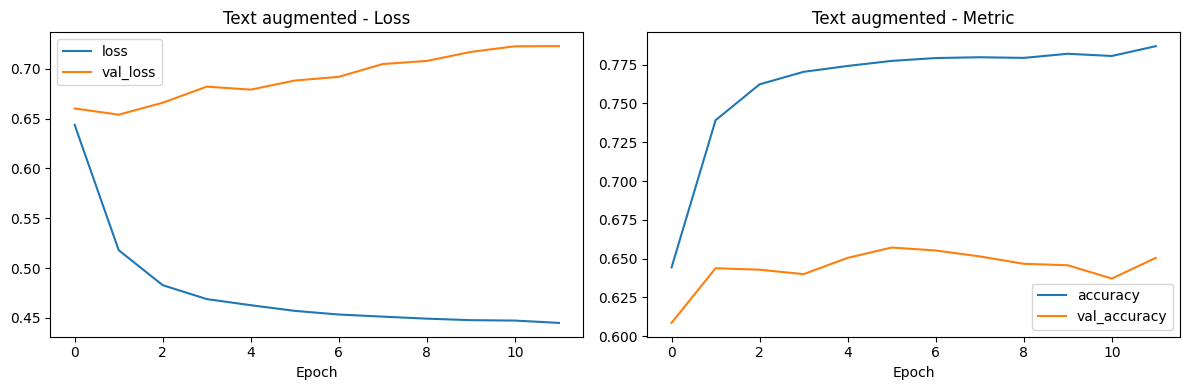

,experiment,best_val_metric,final_train_metric,final_val_metric,test_metric,epochs_ran,generalization_gap
0,text_baseline,0.666667,0.751225,0.646667,0.62,12,0.104558
1,text_augmented,0.657143,0.786939,0.650476,0.62,12,0.136463


In [5]:
text_vectorizer = layers.TextVectorization(max_tokens=1000, output_sequence_length=12)
text_vectorizer.adapt(x_train_text_aug)

def build_text_model():
    return keras.Sequential([
        text_vectorizer,
        layers.Embedding(1000, 16),
        layers.GlobalAveragePooling1D(),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

text_train_ds = tf.data.Dataset.from_tensor_slices((x_train_text, y_train_text)).batch(32).prefetch(AUTO)
text_train_aug_ds = tf.data.Dataset.from_tensor_slices((x_train_text_aug, y_train_text_aug)).shuffle(len(x_train_text_aug), seed=SEED).batch(32).prefetch(AUTO)
text_valid_ds = tf.data.Dataset.from_tensor_slices((x_valid_text, y_valid_text)).batch(32).prefetch(AUTO)
text_test_ds = tf.data.Dataset.from_tensor_slices((x_test_text, y_test_text)).batch(32).prefetch(AUTO)

text_baseline_model = build_text_model()
text_baseline_history, _, text_baseline_test_acc = compile_and_train(
    text_baseline_model,
    text_train_ds,
    text_valid_ds,
    text_test_ds,
    loss="binary_crossentropy",
    metrics=["accuracy"],
    epochs=12,
    verbose=0,
)

text_aug_model = build_text_model()
text_aug_history, _, text_aug_test_acc = compile_and_train(
    text_aug_model,
    text_train_aug_ds,
    text_valid_ds,
    text_test_ds,
    loss="binary_crossentropy",
    metrics=["accuracy"],
    epochs=12,
    verbose=0,
)

plot_history(text_baseline_history, "Text baseline")
plot_history(text_aug_history, "Text augmented")

text_results_df = compare_results([
    summarize_run("text_baseline", text_baseline_history, text_baseline_test_acc),
    summarize_run("text_augmented", text_aug_history, text_aug_test_acc),
])
text_results_df


### Interpretation

Text augmentation changes the wording of the input while preserving the sentiment label.  
The augmented model is expected to rely less on a narrow set of fixed phrases and to generalize better to wording variation.


# 2. Time series augmentation and classification

This section demonstrates augmentation and classification for real-world time series data.

## Task
The dataset used is the UCI Human Activity Recognition (HAR) dataset, which contains smartphone sensor signals collected during human activities.

Each sample is a short time series segment derived from inertial sensors.  
The experiment focuses on three activity classes:
- walking
- walking upstairs
- walking downstairs

The task is to classify each time series into the correct activity category.

## Augmentation strategy
The training time series are augmented using:
- amplitude scaling,
- additive Gaussian noise,
- small temporal shifting,
- localized masking of short segments.

These transformations simulate natural variability in sensor readings while preserving the overall activity pattern.

## Modeling approach
A one-dimensional convolutional neural network is used to learn temporal patterns from the sensor signals.  
The model extracts hierarchical features across time and aggregates them to produce a final classification, while becoming more robust to variations introduced through augmentation.

In [6]:
import os
import zipfile
import shutil
import numpy as np
from tensorflow import keras

def augment_timeseries(x):
    out = x.copy()

    # amplitude scaling
    out = out * np.random.uniform(0.9, 1.1)

    # additive Gaussian noise
    out = out + 0.03 * np.random.randn(*out.shape)

    # circular time shift
    shift = np.random.randint(-5, 6)
    out = np.roll(out, shift)

    # slight local masking
    if np.random.rand() < 0.3:
        start = np.random.randint(0, len(out) - 8)
        width = np.random.randint(4, 10)
        out[start:start + width] = out[start:start + width] * np.random.uniform(0.4, 0.8)

    return out.astype("float32")


# -----------------------------
# Download and load UCI HAR data
# -----------------------------
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = keras.utils.get_file("uci_har_dataset.zip", origin=url)

extract_dir = os.path.join(os.path.dirname(zip_path), "uci_har_clean")

# Force clean extraction
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

base_dir = os.path.join(extract_dir, "UCI HAR Dataset")

x_train_raw = np.loadtxt(os.path.join(base_dir, "train", "Inertial Signals", "body_acc_x_train.txt"))
x_test_raw = np.loadtxt(os.path.join(base_dir, "test", "Inertial Signals", "body_acc_x_test.txt"))

y_train_raw = np.loadtxt(os.path.join(base_dir, "train", "y_train.txt")).astype(int)
y_test_raw = np.loadtxt(os.path.join(base_dir, "test", "y_test.txt")).astype(int)

# Keep only 3 classes so later Dense(3) still works
# 1 = WALKING
# 2 = WALKING_UPSTAIRS
# 3 = WALKING_DOWNSTAIRS
wanted_classes = [1, 2, 3]

train_mask = np.isin(y_train_raw, wanted_classes)
test_mask = np.isin(y_test_raw, wanted_classes)

x_train_raw = x_train_raw[train_mask]
y_train_raw = y_train_raw[train_mask]

x_test_raw = x_test_raw[test_mask]
y_test_raw = y_test_raw[test_mask]

# Remap labels {1,2,3} -> {0,1,2}
label_map = {1: 0, 2: 1, 3: 2}
y_train_raw = np.array([label_map[y] for y in y_train_raw], dtype=np.int32)
y_test_raw = np.array([label_map[y] for y in y_test_raw], dtype=np.int32)

# Normalize using train statistics
mean = x_train_raw.mean()
std = x_train_raw.std() + 1e-8

x_train_raw = ((x_train_raw - mean) / std).astype("float32")
x_test_raw = ((x_test_raw - mean) / std).astype("float32")

# Add channel dimension for Conv1D
x_train_raw = x_train_raw[..., None]
x_test_raw = x_test_raw[..., None]

# Keep the same variable names as the rest of the notebook
series = np.concatenate([x_train_raw, x_test_raw], axis=0).astype("float32")
series_labels = np.concatenate([y_train_raw, y_test_raw], axis=0).astype(np.int32)

idx = np.random.permutation(len(series))
series = series[idx]
series_labels = series_labels[idx]

n_train = int(0.7 * len(series))
n_valid = int(0.85 * len(series))

x_train_ts = series[:n_train]
y_train_ts = series_labels[:n_train]
x_valid_ts = series[n_train:n_valid]
y_valid_ts = series_labels[n_train:n_valid]
x_test_ts = series[n_valid:]
y_test_ts = series_labels[n_valid:]

x_train_ts_aug = np.concatenate(
    [
        x_train_ts,
        np.array([augment_timeseries(x.squeeze())[..., None] for x in x_train_ts], dtype=np.float32),
    ],
    axis=0,
)
y_train_ts_aug = np.concatenate([y_train_ts, y_train_ts], axis=0)

print("Train:", x_train_ts.shape, "Augmented train:", x_train_ts_aug.shape, "Test:", x_test_ts.shape)
print("Class distribution (train):", np.bincount(y_train_ts))
print("Class distribution (valid):", np.bincount(y_valid_ts))
print("Class distribution (test):", np.bincount(y_test_ts))

58179584/Unknown 4s 0us/stepTrain: (3270, 128, 1) Augmented train: (6540, 128, 1) Test: (701, 128, 1)
Class distribution (train): [1209 1066  995]
Class distribution (valid): [255 241 205]
Class distribution (test): [258 237 206]


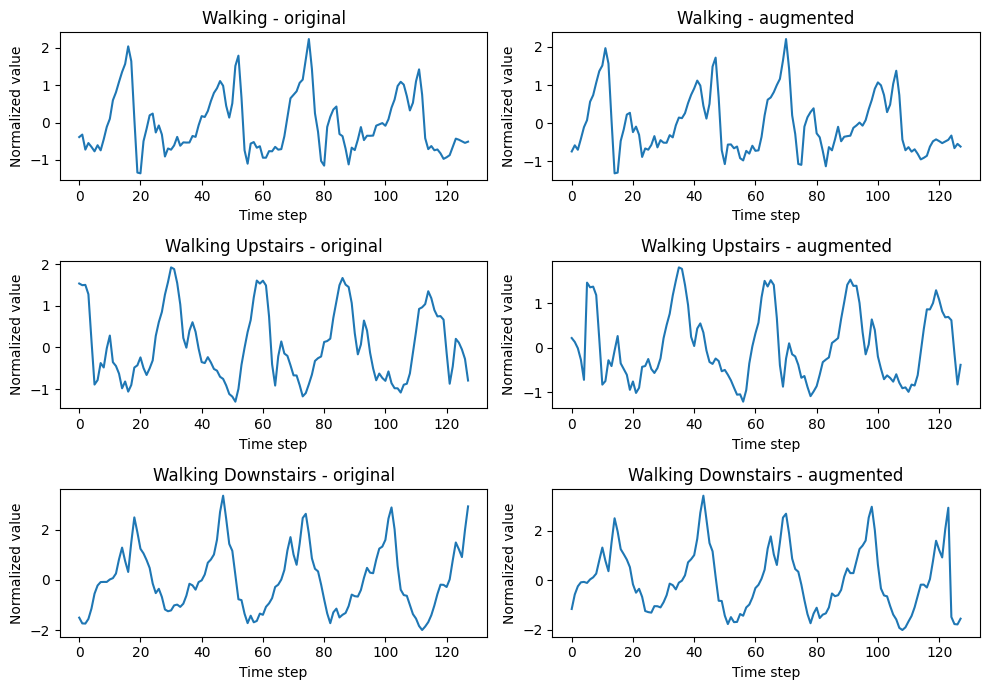

In [7]:
activity_names = ["Walking", "Walking Upstairs", "Walking Downstairs"]

fig, axes = plt.subplots(3, 2, figsize=(10, 7))

for cls in range(3):
    sample_idx = np.where(y_train_ts == cls)[0][0]
    original_series = x_train_ts[sample_idx].squeeze()
    augmented_series = augment_timeseries(original_series)

    axes[cls, 0].plot(original_series)
    axes[cls, 0].set_title(f"{activity_names[cls]} - original")
    axes[cls, 0].set_xlabel("Time step")
    axes[cls, 0].set_ylabel("Normalized value")

    axes[cls, 1].plot(augmented_series)
    axes[cls, 1].set_title(f"{activity_names[cls]} - augmented")
    axes[cls, 1].set_xlabel("Time step")
    axes[cls, 1].set_ylabel("Normalized value")

plt.tight_layout()
plt.show()


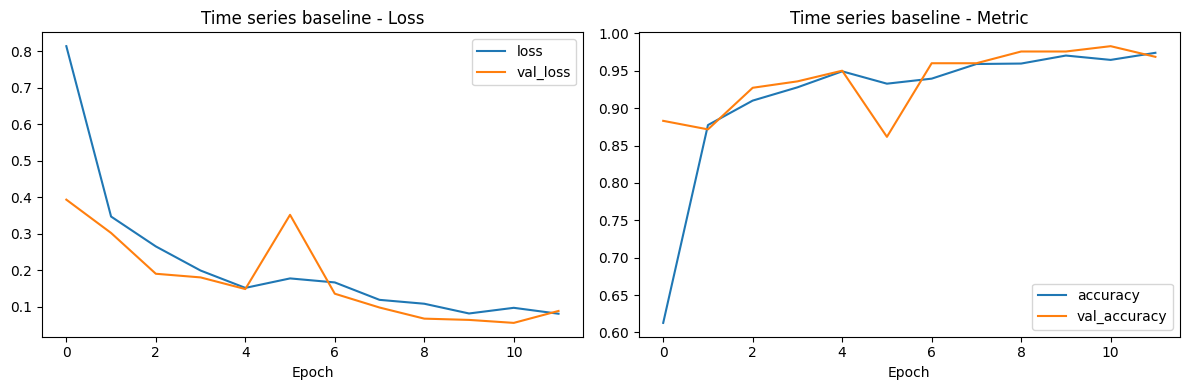

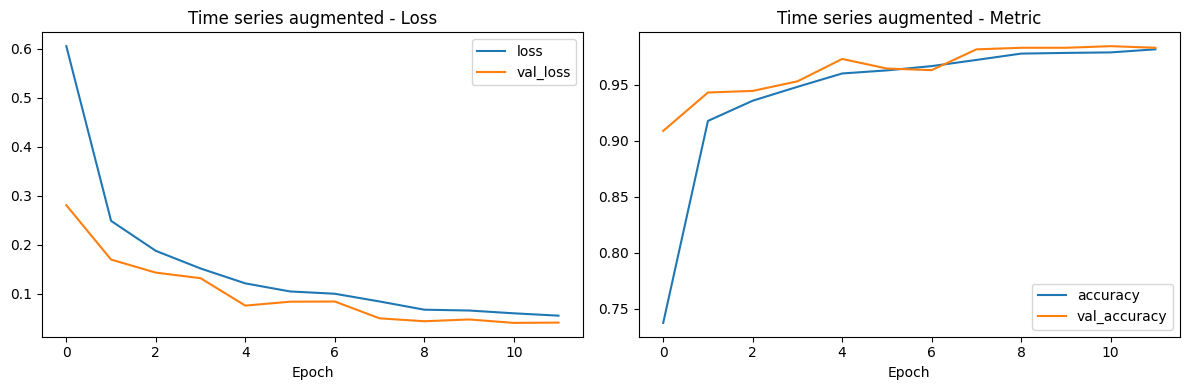

,experiment,best_val_metric,final_train_metric,final_val_metric,test_metric,epochs_ran,generalization_gap
0,timeseries_augmented,0.984308,0.981498,0.982882,0.985735,12,-0.001383
1,timeseries_baseline,0.982882,0.974006,0.968616,0.972896,12,0.005390


In [8]:
def build_timeseries_model():
    input_length = x_train_ts.shape[1]

    return keras.Sequential([
        layers.Input(shape=(input_length, 1)),
        layers.Conv1D(32, 5, activation="relu", padding="same"),
        layers.MaxPooling1D(),
        layers.Conv1D(64, 5, activation="relu", padding="same"),
        layers.MaxPooling1D(),
        layers.Conv1D(128, 3, activation="relu", padding="same"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(3, activation="softmax"),
    ])

ts_train_ds = tf.data.Dataset.from_tensor_slices((x_train_ts, y_train_ts)).shuffle(len(x_train_ts), seed=SEED).batch(32).prefetch(AUTO)
ts_train_aug_ds = tf.data.Dataset.from_tensor_slices((x_train_ts_aug, y_train_ts_aug)).shuffle(len(x_train_ts_aug), seed=SEED).batch(32).prefetch(AUTO)
ts_valid_ds = tf.data.Dataset.from_tensor_slices((x_valid_ts, y_valid_ts)).batch(32).prefetch(AUTO)
ts_test_ds = tf.data.Dataset.from_tensor_slices((x_test_ts, y_test_ts)).batch(32).prefetch(AUTO)

ts_baseline_model = build_timeseries_model()
ts_baseline_history, _, ts_baseline_test_acc = compile_and_train(
    ts_baseline_model,
    ts_train_ds,
    ts_valid_ds,
    ts_test_ds,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    epochs=12,
    verbose=0
)

ts_aug_model = build_timeseries_model()
ts_aug_history, _, ts_aug_test_acc = compile_and_train(
    ts_aug_model,
    ts_train_aug_ds,
    ts_valid_ds,
    ts_test_ds,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    epochs=12,
    verbose=0
)

plot_history(ts_baseline_history, "Time series baseline")
plot_history(ts_aug_history, "Time series augmented")

ts_results_df = compare_results([
    summarize_run("timeseries_baseline", ts_baseline_history, ts_baseline_test_acc),
    summarize_run("timeseries_augmented", ts_aug_history, ts_aug_test_acc),
])
ts_results_df

### Interpretation

For time series, augmentation modifies amplitude, noise level, and local alignment while preserving the underlying waveform type.  
This reduces sensitivity to small signal variations and often improves robustness.


# 3. Tabular data augmentation and classification

This section demonstrates augmentation and classification for structured tabular data.

## Task
The dataset used is the Breast Cancer dataset, which contains numerical features extracted from medical measurements of tumors.  
Each sample represents a set of diagnostic features, and the task is to classify whether the tumor is:
- benign
- malignant

## Augmentation strategy
The training data is augmented using:
- small Gaussian noise added to features,
- minor feature scaling variations.

These transformations simulate measurement variability while preserving the underlying class label.

## Modeling approach
A fully connected neural network is used to learn patterns from the tabular features.  
The model captures relationships between features and becomes more robust to small variations introduced through augmentation.

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
x_tab = data.data.astype("float32")
y_tab = data.target.astype("float32")

# First split: train vs temp
x_train_tab, x_temp_tab, y_train_tab, y_temp_tab = train_test_split(
    x_tab,
    y_tab,
    test_size=0.30,
    random_state=42,
    stratify=y_tab
)

# Second split: valid vs test
x_valid_tab, x_test_tab, y_valid_tab, y_test_tab = train_test_split(
    x_temp_tab,
    y_temp_tab,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_tab
)

# Standardize using training statistics only
scaler = StandardScaler()
x_train_tab = scaler.fit_transform(x_train_tab).astype("float32")
x_valid_tab = scaler.transform(x_valid_tab).astype("float32")
x_test_tab = scaler.transform(x_test_tab).astype("float32")
n_features = x_train_tab.shape[1]

# Keep x_tab consistent with the scaled full dataset
x_tab = scaler.transform(x_tab).astype("float32")

def augment_tabular(x):
    noise = np.random.normal(0, 0.03, size=x.shape)
    scale = np.random.uniform(0.98, 1.02, size=x.shape)
    return (x * scale + noise).astype("float32")

x_train_tab_aug = np.concatenate([x_train_tab, augment_tabular(x_train_tab)], axis=0)
y_train_tab_aug = np.concatenate([y_train_tab, y_train_tab], axis=0)

print("Train:", x_train_tab.shape, "Augmented train:", x_train_tab_aug.shape, "Test:", x_test_tab.shape)

Train: (398, 30) Augmented train: (796, 30) Test: (86, 30)


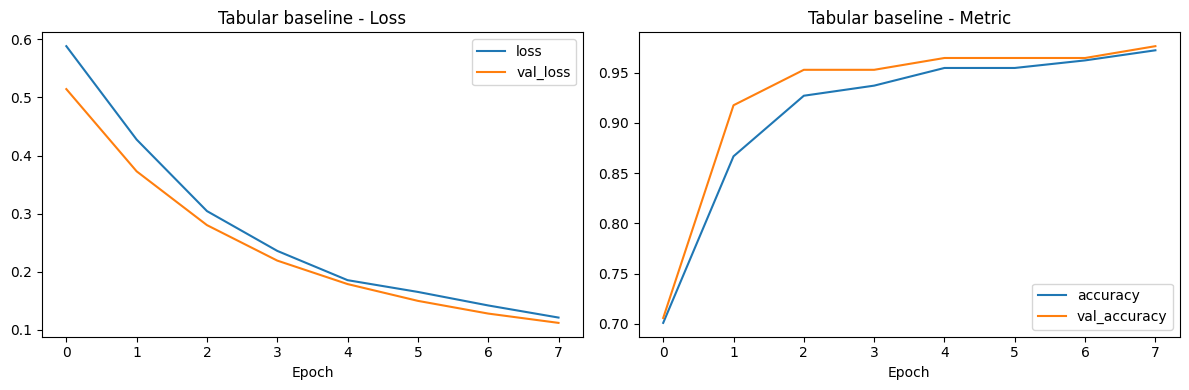

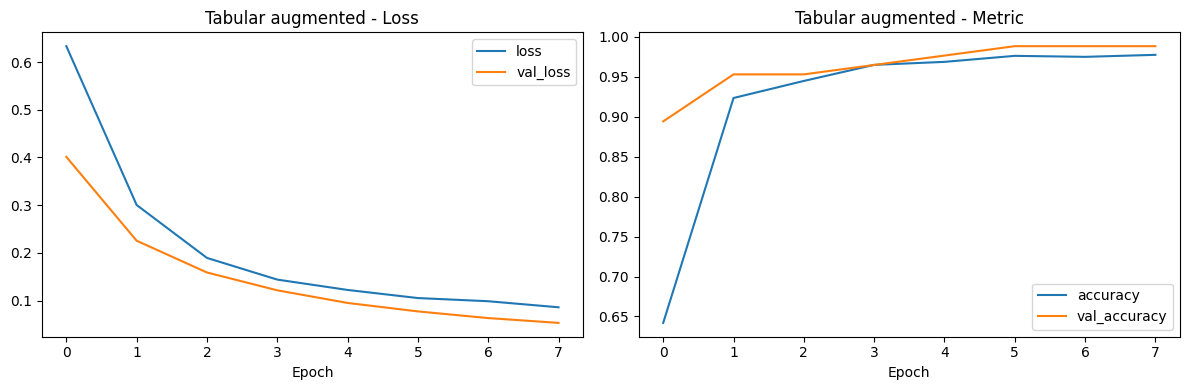

,experiment,best_val_metric,final_train_metric,final_val_metric,test_metric,epochs_ran,generalization_gap
0,tabular_baseline,0.976471,0.972362,0.976471,0.941860,8,-0.004109
1,tabular_augmented,0.988235,0.977387,0.988235,0.930233,8,-0.010848


In [10]:
def build_tabular_model():
    return keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

tab_train_ds = tf.data.Dataset.from_tensor_slices((x_train_tab, y_train_tab)).shuffle(len(x_train_tab), seed=SEED).batch(32).prefetch(AUTO)
tab_train_aug_ds = tf.data.Dataset.from_tensor_slices((x_train_tab_aug, y_train_tab_aug)).shuffle(len(x_train_tab_aug), seed=SEED).batch(32).prefetch(AUTO)
tab_valid_ds = tf.data.Dataset.from_tensor_slices((x_valid_tab, y_valid_tab)).batch(32).prefetch(AUTO)
tab_test_ds = tf.data.Dataset.from_tensor_slices((x_test_tab, y_test_tab)).batch(32).prefetch(AUTO)

tab_baseline_model = build_tabular_model()
tab_baseline_history, _, tab_baseline_test_acc = compile_and_train(
    tab_baseline_model, tab_train_ds, tab_valid_ds, tab_test_ds,
    loss="binary_crossentropy", metrics=["accuracy"], epochs=8, verbose=0
)

tab_aug_model = build_tabular_model()
tab_aug_history, _, tab_aug_test_acc = compile_and_train(
    tab_aug_model, tab_train_aug_ds, tab_valid_ds, tab_test_ds,
    loss="binary_crossentropy", metrics=["accuracy"], epochs=8, verbose=0
)

plot_history(tab_baseline_history, "Tabular baseline")
plot_history(tab_aug_history, "Tabular augmented")

tab_results_df = compare_results([
    summarize_run("tabular_baseline", tab_baseline_history, tab_baseline_test_acc),
    summarize_run("tabular_augmented", tab_aug_history, tab_aug_test_acc),
])
tab_results_df


### Interpretation

Tabular augmentation must be applied carefully because aggressive transformations can distort feature meaning.  
Small noise injection and mild scaling are often reasonable when the features are continuous and the class boundary is stable under local perturbation.


# 4. Speech augmentation and classification

This section demonstrates augmentation for audio waveform classification using real speech data.

## Task
The dataset is constructed from a subset of the Google Speech Commands dataset.  
Each sample is a short audio waveform corresponding to a spoken word.

The experiment uses three classes:
- yes
- no
- up

The task is to classify the waveform into the correct spoken word category.

## Augmentation strategy
The training waveforms are augmented using:
- additive noise,
- amplitude scaling,
- small temporal shifting.

These transformations simulate variations in recording conditions such as background noise, speaking intensity, and timing, while preserving the semantic content of the audio.

## Modeling approach
A one-dimensional convolutional neural network is used to extract temporal features directly from the waveform.  
The model learns to identify patterns in the signal that distinguish between different spoken words while becoming more robust to variations introduced through augmentation.

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


...

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/speech_commands/incomplete.9G9OVG_0.0.3/speech_commands-validation.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/speech_commands/incomplete.9G9OVG_0.0.3/speech_commands-test.tfrecord*...:…

Dataset speech_commands downloaded and prepared to /root/tensorflow_datasets/speech_commands/0.0.3. Subsequent calls will reuse this data.


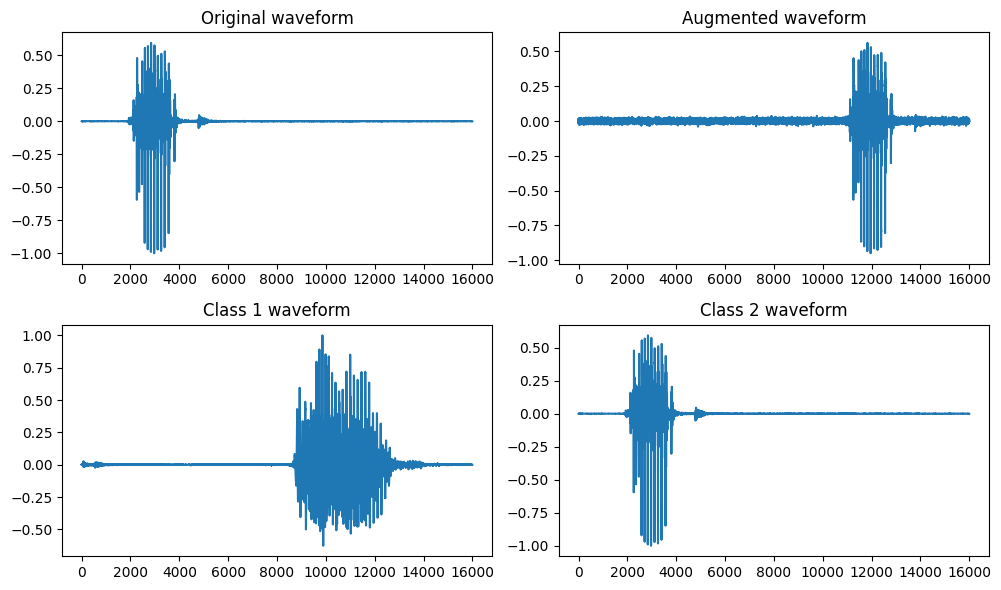

In [11]:
import tensorflow_datasets as tfds

wave_length = 16000
t = np.linspace(0, 1, wave_length, endpoint=False)

label_names = ["yes", "no", "up"]

def _fix_length(audio, target_len=wave_length):
    audio = np.asarray(audio, dtype="float32")

    # Normalize amplitude to roughly [-1, 1]
    max_abs = np.max(np.abs(audio))
    if max_abs > 0:
        audio = audio / max_abs

    if len(audio) < target_len:
        pad = target_len - len(audio)
        audio = np.pad(audio, (0, pad), mode="constant")
    else:
        audio = audio[:target_len]

    return audio.astype("float32")

def augment_speech(x):
    out = x.copy()
    out = out * np.random.uniform(0.85, 1.15)
    out = out + 0.01 * np.random.randn(*out.shape).astype("float32")
    shift = np.random.randint(-10000, 10001)
    out = np.roll(out, shift)
    out = np.clip(out, -1.0, 1.0)
    return out.astype("float32")

def collect_speech_subset(ds, wanted_label_ids, n_per_class):
    speech = []
    speech_labels = []
    counts = {label_id: 0 for label_id in wanted_label_ids}

    for audio, label in tfds.as_numpy(ds):
        label = int(label)
        if label in wanted_label_ids and counts[label] < n_per_class:
            speech.append(_fix_length(audio))
            speech_labels.append(wanted_label_ids.index(label))
            counts[label] += 1

        if all(counts[k] >= n_per_class for k in counts):
            break

    return np.array(speech, dtype="float32"), np.array(speech_labels, dtype=np.int32)

# Load dataset info so we can map class names to label ids
builder = tfds.builder("speech_commands")
builder.download_and_prepare()
info = builder.info
all_label_names = info.features["label"].names

wanted_label_ids = [all_label_names.index(name) for name in label_names]

ds_train_raw = tfds.load("speech_commands", split="train[:20%]", as_supervised=True)
ds_test_raw = tfds.load("speech_commands", split="test[:20%]", as_supervised=True)

n_per_class = 240

speech_train, speech_labels_train = collect_speech_subset(
    ds_train_raw, wanted_label_ids=wanted_label_ids, n_per_class=n_per_class
)

speech_test, speech_labels_test = collect_speech_subset(
    ds_test_raw, wanted_label_ids=wanted_label_ids, n_per_class=max(60, n_per_class // 3)
)

speech = np.concatenate([speech_train, speech_test], axis=0)[..., None]
speech_labels = np.concatenate([speech_labels_train, speech_labels_test], axis=0)

idx = np.random.permutation(len(speech))
speech = speech[idx]
speech_labels = speech_labels[idx]

n_train = int(0.7 * len(speech))
n_valid = int(0.85 * len(speech))

x_train_sp = speech[:n_train]
y_train_sp = speech_labels[:n_train]
x_valid_sp = speech[n_train:n_valid]
y_valid_sp = speech_labels[n_train:n_valid]
x_test_sp = speech[n_valid:]
y_test_sp = speech_labels[n_valid:]

x_train_sp_aug = np.concatenate(
    [x_train_sp, np.array([augment_speech(x.squeeze())[..., None] for x in x_train_sp], dtype="float32")],
    axis=0
)
y_train_sp_aug = np.concatenate([y_train_sp, y_train_sp], axis=0)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes[0, 0].plot(x_train_sp[0].squeeze()); axes[0, 0].set_title("Original waveform")
axes[0, 1].plot(augment_speech(x_train_sp[0].squeeze())); axes[0, 1].set_title("Augmented waveform")
axes[1, 0].plot(x_train_sp[np.where(y_train_sp == 1)[0][0]].squeeze()); axes[1, 0].set_title("Class 1 waveform")
axes[1, 1].plot(x_train_sp[np.where(y_train_sp == 2)[0][0]].squeeze()); axes[1, 1].set_title("Class 2 waveform")
plt.tight_layout()
plt.show()

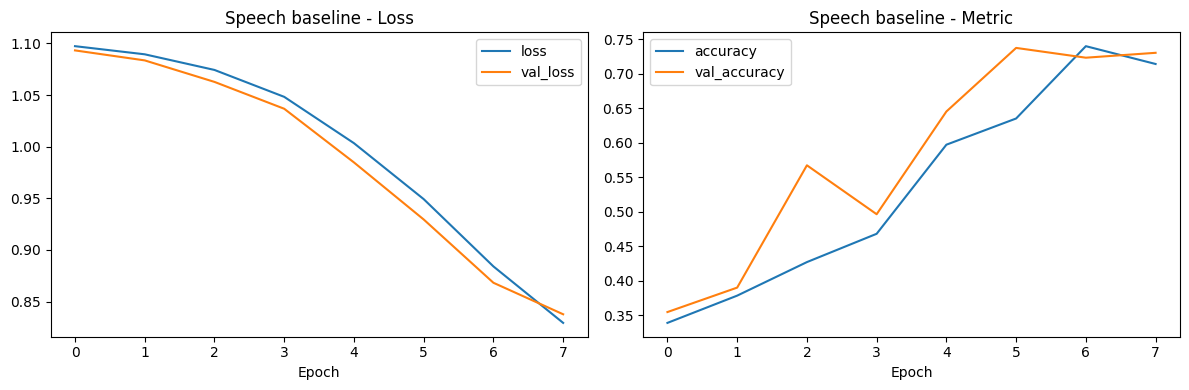

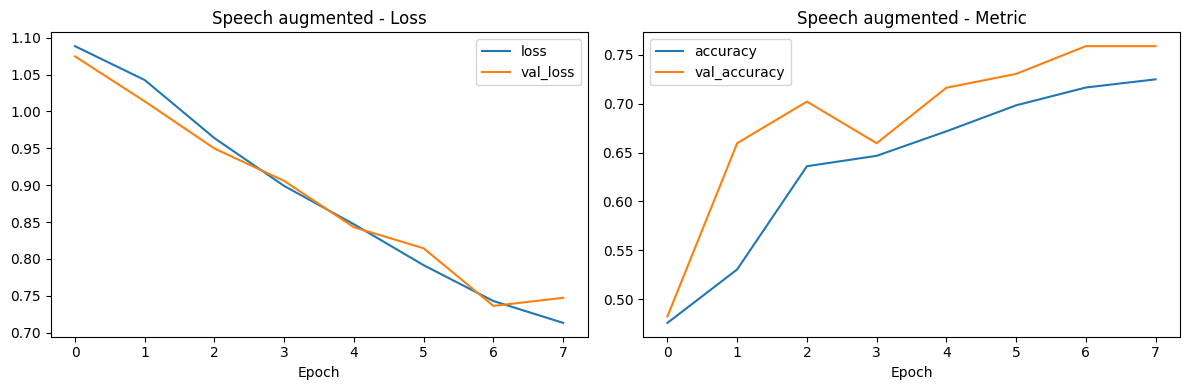

,experiment,best_val_metric,final_train_metric,final_val_metric,test_metric,epochs_ran,generalization_gap
0,speech_augmented,0.758865,0.724924,0.758865,0.774648,8,-0.033941
1,speech_baseline,0.737589,0.714286,0.730496,0.760563,8,-0.016211


In [12]:
def build_speech_model():
    return keras.Sequential([
        layers.Input(shape=(wave_length, 1)),
        layers.Conv1D(32, 7, activation="relu", padding="same"),
        layers.MaxPooling1D(),
        layers.Conv1D(64, 7, activation="relu", padding="same"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dense(3, activation="softmax"),
    ])

sp_train_ds = tf.data.Dataset.from_tensor_slices((x_train_sp, y_train_sp)).shuffle(len(x_train_sp), seed=SEED).batch(32).prefetch(AUTO)
sp_train_aug_ds = tf.data.Dataset.from_tensor_slices((x_train_sp_aug, y_train_sp_aug)).shuffle(len(x_train_sp_aug), seed=SEED).batch(32).prefetch(AUTO)
sp_valid_ds = tf.data.Dataset.from_tensor_slices((x_valid_sp, y_valid_sp)).batch(32).prefetch(AUTO)
sp_test_ds = tf.data.Dataset.from_tensor_slices((x_test_sp, y_test_sp)).batch(32).prefetch(AUTO)

sp_baseline_model = build_speech_model()
sp_baseline_history, _, sp_baseline_test_acc = compile_and_train(
    sp_baseline_model, sp_train_ds, sp_valid_ds, sp_test_ds,
    loss="sparse_categorical_crossentropy", metrics=["accuracy"], epochs=8, verbose=0
)

sp_aug_model = build_speech_model()
sp_aug_history, _, sp_aug_test_acc = compile_and_train(
    sp_aug_model, sp_train_aug_ds, sp_valid_ds, sp_test_ds,
    loss="sparse_categorical_crossentropy", metrics=["accuracy"], epochs=8, verbose=0
)

plot_history(sp_baseline_history, "Speech baseline")
plot_history(sp_aug_history, "Speech augmented")

speech_results_df = compare_results([
    summarize_run("speech_baseline", sp_baseline_history, sp_baseline_test_acc),
    summarize_run("speech_augmented", sp_aug_history, sp_aug_test_acc),
])
speech_results_df


### Interpretation

Speech augmentation changes waveform appearance without changing the underlying frequency class.  
Noise, gain, and small temporal shifts are common audio augmentations because they approximate real-world recording variation.


# 5. Document image augmentation and classification

This section demonstrates image augmentation and classification using grayscale document-style images.

## Task
The dataset used is Fashion MNIST, which consists of grayscale images representing different clothing categories.  
Each image is treated as a simplified document-like visual pattern with structured shapes and textures.

The classification task involves predicting the correct category among multiple classes such as:
- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

## Augmentation strategy
The training set is augmented using:
- small rotations,
- zoom transformations,
- minor shifts in spatial structure.

These transformations preserve the overall shape and identity of the object while introducing variability in appearance.

## Modeling approach
A convolutional neural network is used to extract spatial features from the images.  
The model learns to identify class-specific patterns while becoming more robust to variations introduced through augmentation.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


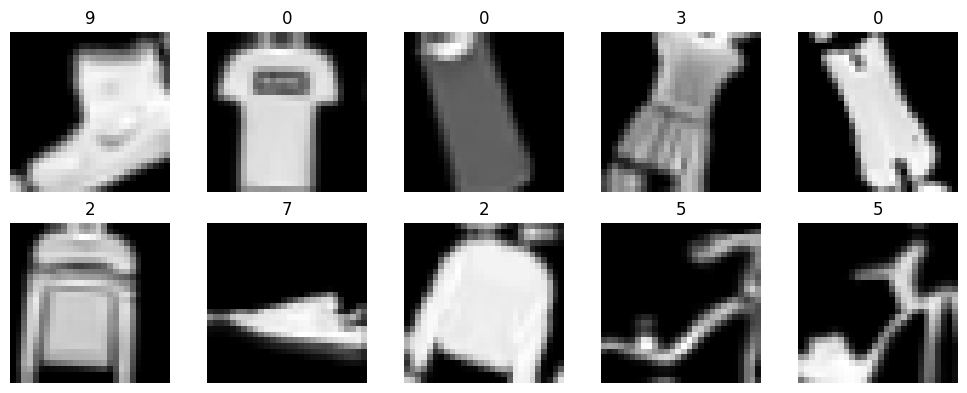

In [13]:
from tensorflow.keras.datasets import fashion_mnist

(x_train_doc_full, y_train_doc_full), (x_test_doc_full, y_test_doc_full) = fashion_mnist.load_data()

x_train_doc_full = x_train_doc_full.astype("float32") / 255.0
x_test_doc_full = x_test_doc_full.astype("float32") / 255.0

x_train_doc_full = x_train_doc_full[..., None]
x_test_doc_full = x_test_doc_full[..., None]

train_subset = 12000
valid_subset = 2000
test_subset = 2000

x_valid_doc = x_train_doc_full[-valid_subset:]
y_valid_doc = y_train_doc_full[-valid_subset:]

x_train_doc = x_train_doc_full[:train_subset]
y_train_doc = y_train_doc_full[:train_subset]

x_test_doc = x_test_doc_full[:test_subset]
y_test_doc = y_test_doc_full[:test_subset]

doc_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
], name="document_augmentation")

def build_augmented_image_ds(x, y, aug_layer, batch_size=128):
    ds = tf.data.Dataset.from_tensor_slices((x, y)).shuffle(len(x), seed=SEED)

    def apply_aug(images, labels):
        images = aug_layer(images, training=True)
        images = tf.clip_by_value(images, 0.0, 1.0)
        return images, labels

    return ds.batch(batch_size).map(apply_aug, num_parallel_calls=AUTO).prefetch(AUTO)

doc_train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train_doc, y_train_doc))
    .shuffle(len(x_train_doc), seed=SEED)
    .batch(128)
    .prefetch(AUTO)
)

doc_train_aug_ds = build_augmented_image_ds(
    x_train_doc, y_train_doc, doc_augmentation, batch_size=128
)

doc_valid_ds = (
    tf.data.Dataset.from_tensor_slices((x_valid_doc, y_valid_doc))
    .batch(128)
    .prefetch(AUTO)
)

doc_test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test_doc, y_test_doc))
    .batch(128)
    .prefetch(AUTO)
)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
aug_batch = doc_augmentation(x_train_doc[:10], training=True)
for i, ax in enumerate(axes.flat):
    ax.imshow(aug_batch[i].numpy().squeeze(), cmap="gray")
    ax.set_title(str(y_train_doc[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()

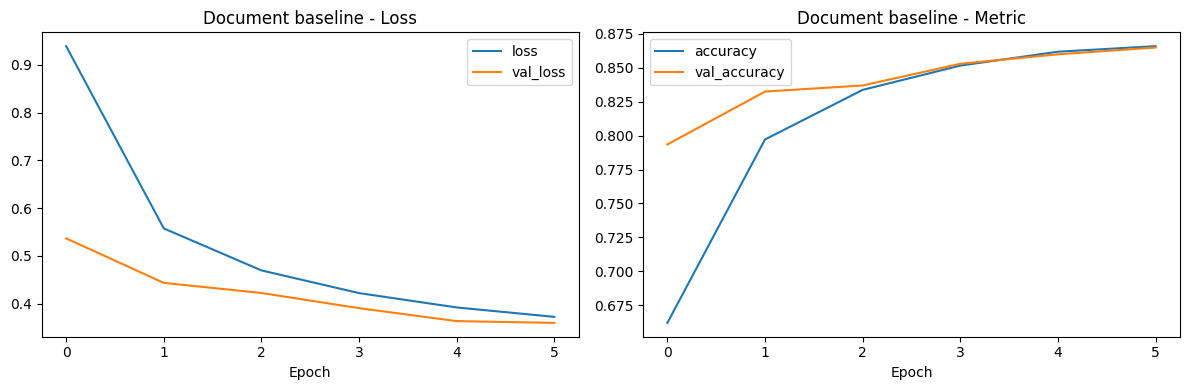

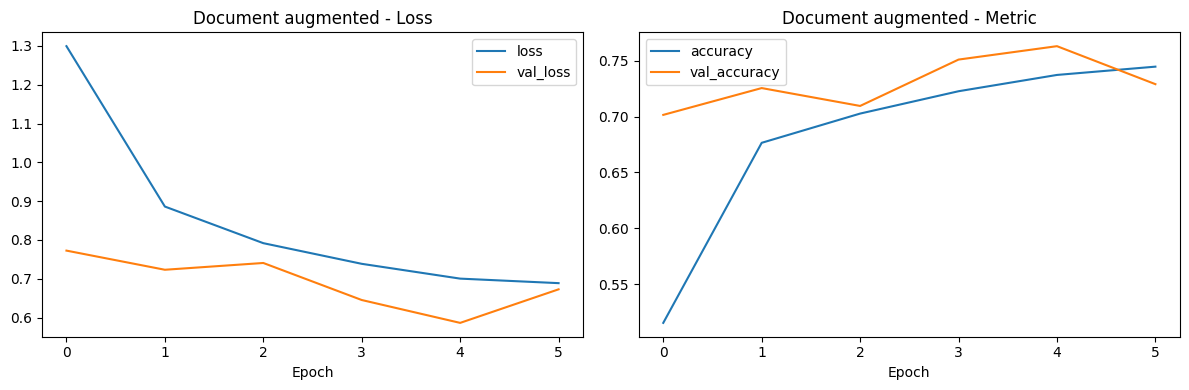

,experiment,best_val_metric,final_train_metric,final_val_metric,test_metric,epochs_ran,generalization_gap
0,document_baseline,0.865,0.866000,0.865,0.866,6,0.001000
1,document_augmented,0.763,0.744667,0.729,0.738,6,0.015667


In [14]:
def build_document_model():
    return keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax"),
    ])

doc_baseline_model = build_document_model()
doc_baseline_history, _, doc_baseline_test_acc = compile_and_train(
    doc_baseline_model, doc_train_ds, doc_valid_ds, doc_test_ds,
    loss="sparse_categorical_crossentropy", metrics=["accuracy"], epochs=6, verbose=0
)

doc_aug_model = build_document_model()
doc_aug_history, _, doc_aug_test_acc = compile_and_train(
    doc_aug_model, doc_train_aug_ds, doc_valid_ds, doc_test_ds,
    loss="sparse_categorical_crossentropy", metrics=["accuracy"], epochs=6, verbose=0
)

plot_history(doc_baseline_history, "Document baseline")
plot_history(doc_aug_history, "Document augmented")

doc_results_df = compare_results([
    summarize_run("document_baseline", doc_baseline_history, doc_baseline_test_acc),
    summarize_run("document_augmented", doc_aug_history, doc_aug_test_acc),
])
doc_results_df


### Interpretation

Document-image augmentation helps the model handle small scanning, alignment, and contrast changes.  
This is especially useful when the deployment inputs may contain shifted, tilted, or unevenly illuminated document characters.


# 6. Video augmentation and classification

This section demonstrates video classification using short frame sequences constructed from real image data.

## Task
Video samples are created by grouping consecutive images from CIFAR-10 into short sequences.  
Each video consists of multiple frames, and the label corresponds to the object class.

The experiment uses three classes:
- airplane
- automobile
- bird

Each sequence represents a simplified video clip where the object category remains consistent across frames.

## Augmentation strategy
Video augmentation is applied at the frame level using:
- horizontal flipping,
- small rotations,
- brightness scaling,
- additive noise.

These transformations preserve the semantic content of each frame while introducing variability in appearance.

## Modeling approach
A TimeDistributed convolutional network is used to extract features from each frame.  
Temporal information is aggregated across frames to produce a final classification for the video sequence.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


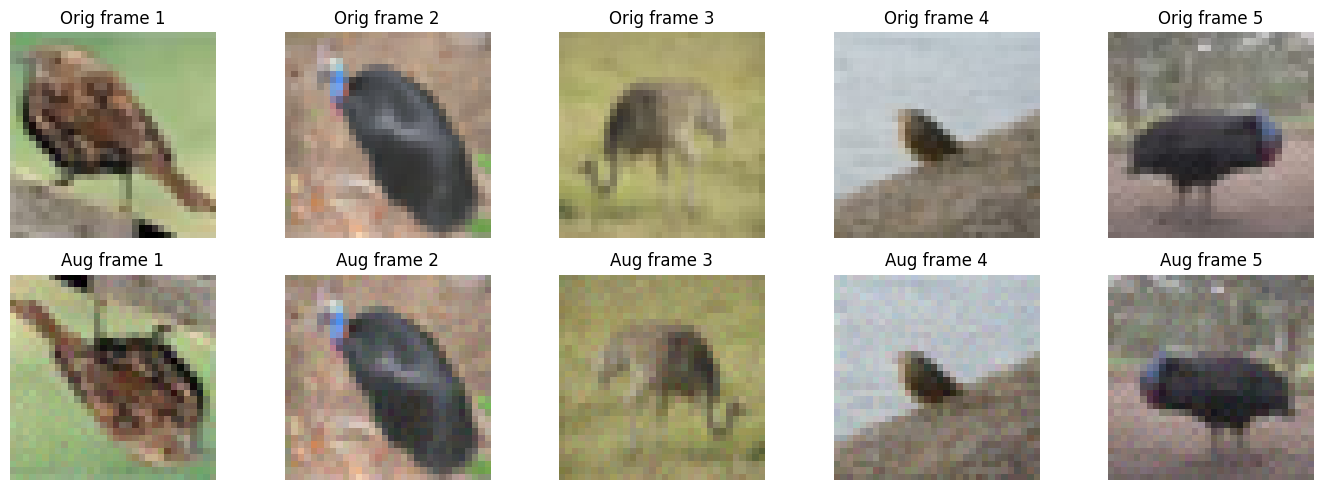

In [15]:
from tensorflow.keras.datasets import cifar10

num_frames = 5
video_classes_to_use = [0, 1, 2]  # airplane, automobile, bird
video_class_names = ["airplane", "automobile", "bird"]

(x_train_vid_full, y_train_vid_full), (x_test_vid_full, y_test_vid_full) = cifar10.load_data()
y_train_vid_full = y_train_vid_full.squeeze()
y_test_vid_full = y_test_vid_full.squeeze()

x_train_vid_full = x_train_vid_full.astype("float32") / 255.0
x_test_vid_full = x_test_vid_full.astype("float32") / 255.0

train_mask = np.isin(y_train_vid_full, video_classes_to_use)
test_mask = np.isin(y_test_vid_full, video_classes_to_use)

x_train_vid_full = x_train_vid_full[train_mask]
y_train_vid_full = y_train_vid_full[train_mask]
x_test_vid_full = x_test_vid_full[test_mask]
y_test_vid_full = y_test_vid_full[test_mask]

label_map = {old: new for new, old in enumerate(video_classes_to_use)}
y_train_vid_full = np.array([label_map[y] for y in y_train_vid_full], dtype=np.int32)
y_test_vid_full = np.array([label_map[y] for y in y_test_vid_full], dtype=np.int32)

def make_video_sequences(x, y, num_frames=5):
    videos = []
    video_labels = []

    for class_id in range(len(video_classes_to_use)):
        class_x = x[y == class_id]
        usable = (len(class_x) // num_frames) * num_frames
        class_x = class_x[:usable]

        if usable == 0:
            continue

        class_videos = class_x.reshape(-1, num_frames, 32, 32, 3)
        class_labels = np.full(len(class_videos), class_id, dtype=np.int32)

        videos.append(class_videos)
        video_labels.append(class_labels)

    videos = np.concatenate(videos, axis=0)
    video_labels = np.concatenate(video_labels, axis=0)

    idx = np.random.permutation(len(videos))
    return videos[idx], video_labels[idx]

videos_train_full, labels_train_full = make_video_sequences(x_train_vid_full, y_train_vid_full, num_frames=num_frames)
videos_test_full, labels_test_full = make_video_sequences(x_test_vid_full, y_test_vid_full, num_frames=num_frames)

# keep it lightweight for Colab
videos_train_full = videos_train_full[:900]
labels_train_full = labels_train_full[:900]
videos_test_full = videos_test_full[:180]
labels_test_full = labels_test_full[:180]

n_valid = int(0.2 * len(videos_train_full))

x_valid_vid = videos_train_full[:n_valid]
y_valid_vid = labels_train_full[:n_valid]

x_train_vid = videos_train_full[n_valid:]
y_train_vid = labels_train_full[n_valid:]

x_test_vid = videos_test_full
y_test_vid = labels_test_full

def augment_video(video):
    augmented_frames = []
    for frame in video:
        aug_frame = frame.copy()

        if np.random.rand() < 0.5:
            aug_frame = np.fliplr(aug_frame)

        k = np.random.choice([0, 1, 2, 3], p=[0.5, 0.2, 0.2, 0.1])
        aug_frame = np.rot90(aug_frame, k=k)

        noise = 0.02 * np.random.randn(*aug_frame.shape)
        aug_frame = aug_frame + noise

        brightness = np.random.uniform(0.9, 1.1)
        aug_frame = aug_frame * brightness

        aug_frame = np.clip(aug_frame, 0.0, 1.0).astype("float32")
        augmented_frames.append(aug_frame)

    return np.array(augmented_frames, dtype="float32")

x_train_vid_aug = np.concatenate(
    [x_train_vid, np.array([augment_video(v) for v in x_train_vid], dtype="float32")],
    axis=0
)
y_train_vid_aug = np.concatenate([y_train_vid, y_train_vid], axis=0)

fig, axes = plt.subplots(2, num_frames, figsize=(14, 5))
for i in range(num_frames):
    axes[0, i].imshow(x_train_vid[0][i])
    axes[0, i].set_title(f"Orig frame {i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(augment_video(x_train_vid[0])[i])
    axes[1, i].set_title(f"Aug frame {i+1}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [16]:
def build_video_model():
    inputs = keras.Input(shape=(num_frames, 32, 32, 3))

    x = layers.TimeDistributed(layers.Conv2D(16, 3, activation="relu", padding="same"))(inputs)
    x = layers.TimeDistributed(layers.MaxPooling2D())(x)
    x = layers.TimeDistributed(layers.Conv2D(32, 3, activation="relu", padding="same"))(x)
    x = layers.TimeDistributed(layers.MaxPooling2D())(x)
    x = layers.TimeDistributed(layers.Conv2D(64, 3, activation="relu", padding="same"))(x)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(video_classes_to_use), activation="softmax")(x)

    return keras.Model(inputs, outputs)

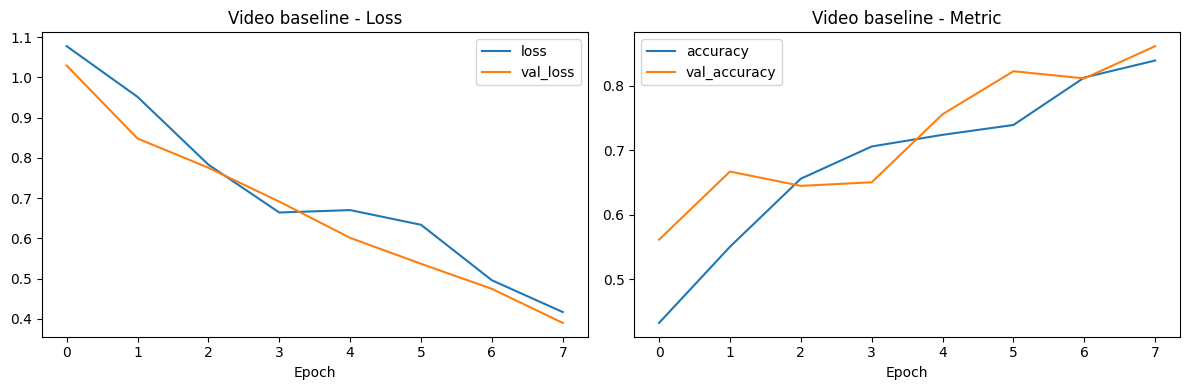

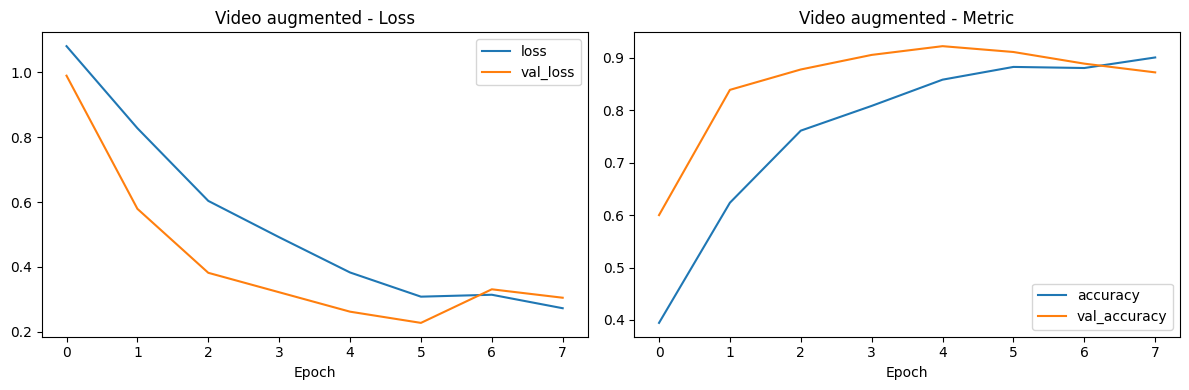

,experiment,best_val_metric,final_train_metric,final_val_metric,test_metric,epochs_ran,generalization_gap
0,video_baseline,0.861111,0.838889,0.861111,0.888889,8,-0.022222
1,video_augmented,0.922222,0.900694,0.872222,0.855556,8,0.028472


In [17]:
vid_train_ds = tf.data.Dataset.from_tensor_slices((x_train_vid, y_train_vid)).shuffle(len(x_train_vid), seed=SEED).batch(32).prefetch(AUTO)
vid_train_aug_ds = tf.data.Dataset.from_tensor_slices((x_train_vid_aug, y_train_vid_aug)).shuffle(len(x_train_vid_aug), seed=SEED).batch(32).prefetch(AUTO)
vid_valid_ds = tf.data.Dataset.from_tensor_slices((x_valid_vid, y_valid_vid)).batch(32).prefetch(AUTO)
vid_test_ds = tf.data.Dataset.from_tensor_slices((x_test_vid, y_test_vid)).batch(32).prefetch(AUTO)

vid_baseline_model = build_video_model()
vid_baseline_history, _, vid_baseline_test_acc = compile_and_train(
    vid_baseline_model,
    vid_train_ds,
    vid_valid_ds,
    vid_test_ds,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    epochs=8,
    verbose=0
)

vid_aug_model = build_video_model()
vid_aug_history, _, vid_aug_test_acc = compile_and_train(
    vid_aug_model,
    vid_train_aug_ds,
    vid_valid_ds,
    vid_test_ds,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    epochs=8,
    verbose=0
)

plot_history(vid_baseline_history, "Video baseline")
plot_history(vid_aug_history, "Video augmented")

video_results_df = compare_results([
    summarize_run("video_baseline", vid_baseline_history, vid_baseline_test_acc),
    summarize_run("video_augmented", vid_aug_history, vid_aug_test_acc),
])

video_results_df

### Interpretation

Video augmentation applies the same label-preserving idea used in image augmentation, but across spatiotemporal inputs.  
Flipping, brightness changes, and additive noise are simple examples of perturbations that can increase robustness when the class label remains unchanged.


# Final experiment summary

The table below collects the baseline and augmented results across all modalities in this notebook.


In [18]:
all_results = []

for modality_name, baseline_hist, baseline_acc, aug_hist, aug_acc in [
    ("text", text_baseline_history, text_baseline_test_acc, text_aug_history, text_aug_test_acc),
    ("timeseries", ts_baseline_history, ts_baseline_test_acc, ts_aug_history, ts_aug_test_acc),
    ("tabular", tab_baseline_history, tab_baseline_test_acc, tab_aug_history, tab_aug_test_acc),
    ("speech", sp_baseline_history, sp_baseline_test_acc, sp_aug_history, sp_aug_test_acc),
    ("document", doc_baseline_history, doc_baseline_test_acc, doc_aug_history, doc_aug_test_acc),
    ("video", vid_baseline_history, vid_baseline_test_acc, vid_aug_history, vid_aug_test_acc),
]:
    all_results.append({
        "modality": modality_name,
        "baseline_test_metric": float(baseline_acc),
        "augmented_test_metric": float(aug_acc),
        "improvement": float(aug_acc - baseline_acc),
    })

summary_df = pd.DataFrame(all_results).sort_values("improvement", ascending=False).reset_index(drop=True)
summary_df


,modality,baseline_test_metric,augmented_test_metric,improvement
0,speech,0.760563,0.774648,0.014085
1,timeseries,0.972896,0.985735,0.012839
2,text,0.620000,0.620000,0.000000
3,tabular,0.941860,0.930233,-0.011628
4,video,0.888889,0.855556,-0.033333
5,document,0.866000,0.738000,-0.128000


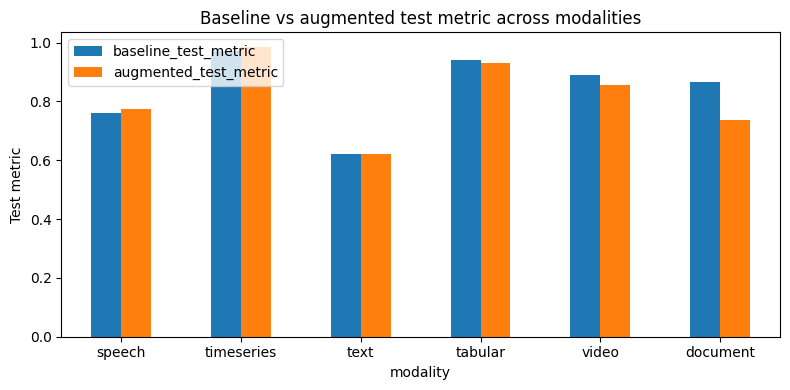

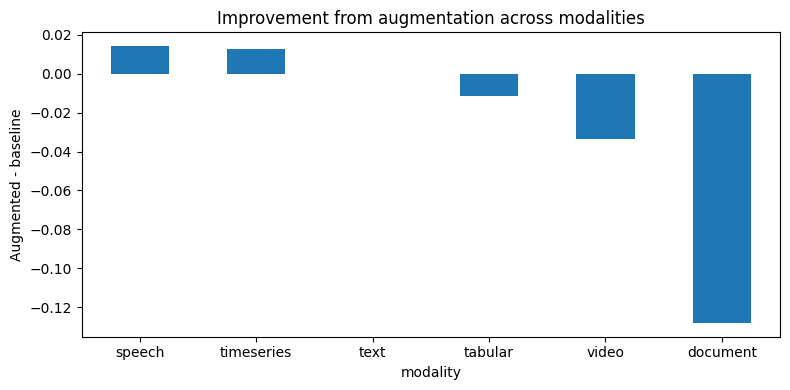

In [19]:
plot_df = summary_df.set_index("modality")[["baseline_test_metric", "augmented_test_metric"]]
ax = plot_df.plot(kind="bar", rot=0)
ax.set_title("Baseline vs augmented test metric across modalities")
ax.set_ylabel("Test metric")
plt.tight_layout()
plt.show()

ax = summary_df.set_index("modality")["improvement"].plot(kind="bar", rot=0)
ax.set_title("Improvement from augmentation across modalities")
ax.set_ylabel("Augmented - baseline")
plt.tight_layout()
plt.show()


## Key conclusions

This notebook highlights the following ideas:

1. **Augmentation is not limited to image classification.**  
   It can be applied to text, time series, tabular data, speech, document images, and video.

2. **The augmentation strategy depends on the modality.**  
   Each data type requires transformations that preserve the label while increasing input diversity.

3. **Lower training performance does not automatically imply worse generalization.**  
   Augmentation can make training more challenging while still improving validation or test behavior.

4. **The same baseline-vs-augmented comparison pattern extends naturally across modalities.**  
   This makes augmentation a general regularization strategy rather than a modality-specific trick.

5. **Compact synthetic or lightweight datasets are sufficient to demonstrate the augmentation principle clearly.**  
   The purpose of this notebook is conceptual coverage and runnable implementation across multiple data types.

## Covered modalities in this notebook

- text
- time series
- tabular data
- speech
- document images
- video
